<a href="https://colab.research.google.com/github/jeombagis/Stock-price-prediction/blob/main/Git_Stock_Classification_TMY_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
tmy_path = '/content/drive/MyDrive/Jeombagis/DongnaeFriends/StockPricePrediction/Internal_Build_Ver/TMY'
if os.path.exists(tmy_path):
    print(f"'{tmy_path}' 내 파일 목록:")
    print(os.listdir(tmy_path))
else:
    print(f"❌ '{tmy_path}' 경로가 존재하지 않습니다. 드라이브 마운트 상태나 폴더명을 확인해주세요.")

'/content/drive/MyDrive/Jeombagis/DongnaeFriends/StockPricePrediction/Internal_Build_Ver/TMY' 내 파일 목록:
['폐기 csv', 'SnP500_60years_daily.csv', 'Nasdaq100_60years_daily.csv', 'Data_extraction_TMY.ipynb', 'Stock_Classification_TMY_V1.ipynb']


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==========================================
# 1. 환경 설정 (Configuration)
# ==========================================
class Config:
    # 분석 및 학습에 사용할 데이터 소스 경로 (Google Drive)
    DATA_SOURCES = {
        'S&P 500': '/content/drive/MyDrive/Jeombagis/DongnaeFriends/StockPricePrediction/Internal_Build_Ver/TMY/SnP500_60years_daily.csv',
        'Nasdaq 100': '/content/drive/MyDrive/Jeombagis/DongnaeFriends/StockPricePrediction/Internal_Build_Ver/TMY/Nasdaq100_60years_daily.csv'
    }
    WINDOW_SIZE = 5      # 과거 며칠간의 데이터를 특징(Feature)으로 사용할지 설정
    THRESHOLD = 0.002    # '상승'으로 판단할 수익률 임계값 (0.2% 이상 시 1, 미만 시 0)
    TRAIN_SPLIT = 0.8    # 전체 데이터 중 학습에 사용할 비율 (80% 학습, 20% 테스트)

# ==========================================
# 2. 데이터 처리 클래스 (Data Processing)
# ==========================================
class DataProcessor:
    """데이터 로딩, 기술적 지표 계산 및 피처 엔지니어링 수행"""
    def __init__(self, file_path):
        self.file_path = file_path
        self.features = []

    def load_and_clean(self):
        """CSV 로드 및 기본 전처리 (날짜 정렬 및 수치형 변환)"""
        df = pd.read_csv(self.file_path)
        df.columns = [c.lower() for c in df.columns]
        df = df.sort_values(by='date').reset_index(drop=True)
        cols = ['open', 'high', 'low', 'close', 'volume']
        df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
        return df

    def add_features(self, df):
        """머신러닝 학습을 위한 보조지표 및 Lag 데이터 생성"""
        # 기본 변동성 지표
        df['return'] = df['close'].pct_change()        # 일일 수익률
        df['vol_change'] = df['volume'].pct_change()   # 거래량 변화율
        df['high_low_gap'] = (df['high'] - df['low']) / df['open'] # 고가-저가 차이

        # RSI (Relative Strength Index)
        delta = df['close'].diff()
        gain = delta.where(delta > 0, 0).rolling(window=14).mean()
        loss = -delta.where(delta < 0, 0).rolling(window=14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))

        # MACD
        exp1 = df['close'].ewm(span=12, adjust=False).mean()
        exp2 = df['close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = exp1 - exp2
        df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

        # --- [추가 지표 1] Bollinger Bands ---
        df['MA20'] = df['close'].rolling(window=20).mean()
        df['std20'] = df['close'].rolling(window=20).std()
        df['BB_Upper'] = df['MA20'] + (df['std20'] * 2)
        df['BB_Lower'] = df['MA20'] - (df['std20'] * 2)
        df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['MA20']

        # --- [추가 지표 2] Stochastic Oscillator ---
        low_min = df['low'].rolling(window=14).min()
        high_max = df['high'].rolling(window=14).max()
        df['Stochastic_K'] = 100 * (df['close'] - low_min) / (high_max - low_min)
        df['Stochastic_D'] = df['Stochastic_K'].rolling(window=3).mean()

        # --- [추가 지표 3] ATR (Average True Range) ---
        tr = pd.concat([df['high'] - df['low'],
                        abs(df['high'] - df['close'].shift()),
                        abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
        df['ATR'] = tr.rolling(window=14).mean()

        # 시차(Lag) 피처
        for i in range(1, Config.WINDOW_SIZE + 1):
            df[f'return_lag_{i}'] = df['return'].shift(i)
            df[f'vol_lag_{i}'] = df['vol_change'].shift(i)

        # 피처 리스트 업데이트
        self.features = ['return', 'vol_change', 'high_low_gap', 'RSI', 'MACD', 'MACD_Signal',
                        'BB_Width', 'Stochastic_K', 'Stochastic_D', 'ATR'] + \
                        [f'return_lag_{i}' for i in range(1, Config.WINDOW_SIZE + 1)] + \
                        [f'vol_lag_{i}' for i in range(1, Config.WINDOW_SIZE + 1)]

        # 타겟 데이터
        df['target'] = (df['return'].shift(-1) > Config.THRESHOLD).astype(int)

        # 무한값 및 결측치 제거
        df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
        return df

    def split_data(self, df):
        """데이터를 시계열 순서에 맞게 학습용과 검증용으로 분리"""
        X = df[self.features]
        y = df['target']
        split_idx = int(len(df) * Config.TRAIN_SPLIT)
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]
        df_test = df.iloc[split_idx:].copy()
        df_test['Next_Return'] = df_test['return'].shift(-1).fillna(0)
        return X_train, X_test, y_train, y_test, df_test

# ==========================================
# 3. 모델 관리 클래스 (Model Management)
# ==========================================
class ModelManager:
    """AI 분류 모델 구성 및 학습 관리"""
    def __init__(self):
        self.models = {
            'XGB': XGBClassifier(n_estimators=200, learning_rate=0.03, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42),
            'RF': RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42)
        }

    def train_and_predict(self, X_train, y_train, X_test):
        """정의된 모든 모델을 주어진 학습 데이터로 훈련"""
        for name, model in self.models.items():
            model.fit(X_train, y_train)

# ==========================================
# 4. 메인 실행 프로세스
# ==========================================
if __name__ == "__main__":
    for asset_name, path in Config.DATA_SOURCES.items():
        if not os.path.exists(path):
            print(f"❌ 파일을 찾을 수 없습니다: {path}")
            continue

        print(f"\n🚀 {asset_name} 업그레이드된 AI 파이프라인 가동 (지표 추가)... ")
        processor = DataProcessor(path)
        raw_df = processor.load_and_clean()
        processed_df = processor.add_features(raw_df)
        X_train, X_test, y_train, y_test, df_test = processor.split_data(processed_df)
        model_manager = ModelManager()
        model_manager.train_and_predict(X_train, y_train, X_test)
        print(f"✅ {asset_name} 파이프라인 완료")


🚀 S&P 500 업그레이드된 AI 파이프라인 가동 (지표 추가)... 
✅ S&P 500 파이프라인 완료

🚀 Nasdaq 100 업그레이드된 AI 파이프라인 가동 (지표 추가)... 
✅ Nasdaq 100 파이프라인 완료



📊 Nasdaq 100 모델 피처 중요도 분석:


/tmp/ipykernel_4495/436711398.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')


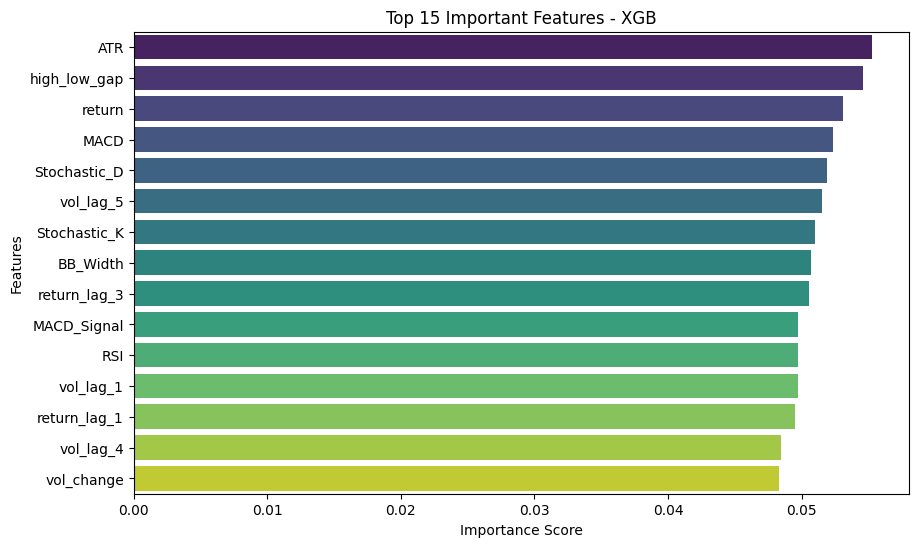

/tmp/ipykernel_4495/436711398.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')


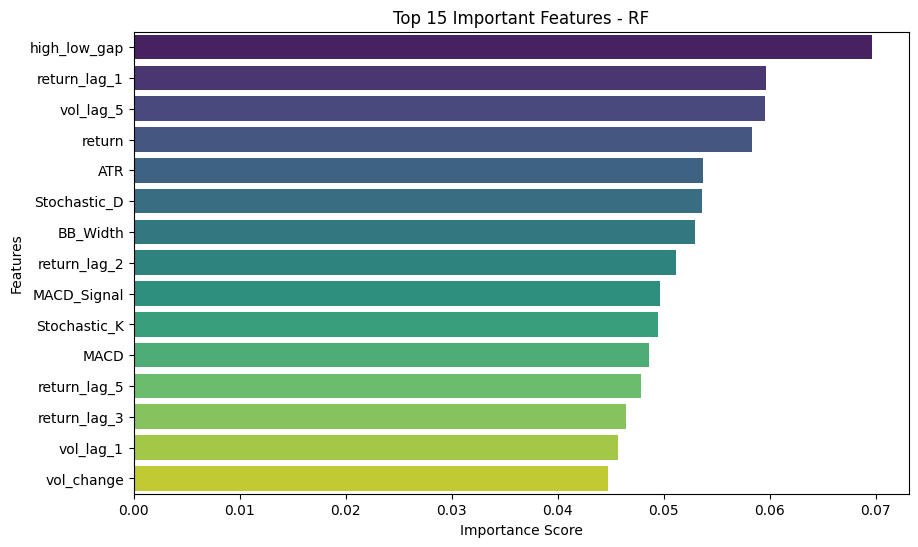

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model_manager, features):
    """학습된 모델들의 피처 중요도를 시각화합니다."""
    for name, model in model_manager.models.items():
        importance = model.feature_importances_
        # 피처 이름과 중요도를 매칭하여 데이터프레임 생성
        feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importance})
        feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')
        plt.title(f'Top 15 Important Features - {name}')
        plt.xlabel('Importance Score')
        plt.ylabel('Features')
        plt.show()

# 마지막으로 분석된 자산의 모델 정보를 바탕으로 중요도 출력
print(f"\n📊 {asset_name} 모델 피처 중요도 분석:")
plot_feature_importance(model_manager, processor.features)

In [ ]:
from datetime import datetime, timedelta

def get_next_day_prediction(asset_name, processor, model_manager):
    """가장 최근 데이터를 바탕으로 내일의 주가 상승/하락 예측 결과 제공"""
    # 1. 가장 최근(마지막 행) 데이터 추출
    last_row_features = X_test.iloc[[-1]]
    last_row_full = df_test.iloc[-1]

    # 날짜 처리 (YYYYMMDD 숫자를 날짜 객체로 변환)
    last_date_str = str(int(last_row_full['date']))
    last_date_obj = datetime.strptime(last_date_str, '%Y%m%d')
    # 다음 거래일 계산
    next_date_obj = last_date_obj + timedelta(days=1)

    # 2. 모델별 예측 (1: 상승, 0: 하락/보합)
    predictions = {}
    for name, model in model_manager.models.items():
        pred = model.predict(last_row_features)[0]
        prob = model.predict_proba(last_row_features)[0][1] # 상승 확률
        predictions[name] = {'signal': pred, 'prob': prob}

    # 3. 결과 리포트 출력
    print(f"\n{'='*60}")
    print(f" 📈 [ {asset_name} - AI 주가 예측 리포트 ] ")
    print(f"{'='*60}")
    print(f" 📅 [1] 데이터 기준 거래일  : {last_date_obj.strftime('%Y-%m-%d')}")
    print(f" 🎯 [2] 예측 대상 목표일    : {next_date_obj.strftime('%Y-%m-%d')} (익일)")
    print(f"{'='*60}")

    print(f"[AI 모델별 분석 결과]")
    for name, res in predictions.items():
        direction = "상승 우세 ↑" if res['signal'] == 1 else "하락/보합 우세 ↓"
        print(f" - {name:<4}: {direction} (상승 확률: {res['prob']*100:.1f}%)")

    print(f"\n[종합 의견]")
    # 두 모델의 평균 확률 계산
    avg_prob = sum(res['prob'] for res in predictions.values()) / len(predictions)
    if avg_prob >= 0.6:
        opinion = "상승 가능성이 높습니다. 긍정적인 관점을 유지하세요."
    elif avg_prob >= 0.45:
        opinion = "방향성이 모호합니다. 시장 상황을 좀 더 관망하세요."
    else:
        opinion = "하락 또는 보합 가능성이 높으므로 주의가 필요합니다."

    print(f" ➔ {opinion}")
    print(f"{'='*60}")

# Nasdaq 100 기준으로 예측 실행 (backtester 인자 제거)
get_next_day_prediction("Nasdaq 100", processor, model_manager)


 📈 [ Nasdaq 100 - AI 주가 예측 리포트 ] 
 📅 [1] 데이터 기준 거래일  : 2026-04-15
 🎯 [2] 예측 대상 목표일    : 2026-04-16 (익일)
[AI 모델별 분석 결과]
 - XGB : 하락/보합 우세 ↓ (상승 확률: 41.7%)
 - RF  : 하락/보합 우세 ↓ (상승 확률: 46.9%)

[종합 의견]
 ➔ 하락 또는 보합 가능성이 높으므로 주의가 필요합니다.


In [ ]:
from datetime import datetime, timedelta
import pandas as pd

def show_last_month_performance(asset_name, processor, model_manager, df_test, X_test):
    """최근 한 달간(20거래일)의 일별 AI 예측 결과(확률 포함)를 요약하여 출력합니다."""
    print(f"\n{'='*90}")
    print(f" 📊 [ {asset_name} - 최근 20거래일 AI 예측 상세 히스토리 ] ")
    print(f"{'='*90}")
    print(f" {'기준 거래일':<11} | {'예측 목표일':<11} | {'XGB 예측(확률)':<18} | {'RF 예측(확률)':<18}")
    print(f" {'-'*88}")

    # 최근 20개 데이터 추출
    lookback_period = 20
    recent_X = X_test.tail(lookback_period)
    recent_df = df_test.tail(lookback_period)

    for i in range(len(recent_df)):
        row = recent_df.iloc[i]
        feat = recent_X.iloc[[i]]

        # 날짜 계산
        base_date = datetime.strptime(str(int(row['date'])), '%Y%m%d')
        target_date = base_date + timedelta(days=1)

        # 모델 예측 및 확률 추출
        xgb_prob = model_manager.models['XGB'].predict_proba(feat)[0][1]
        rf_prob = model_manager.models['RF'].predict_proba(feat)[0][1]

        xgb_label = "상승" if xgb_prob > 0.5 else "하락"
        rf_label = "상승" if rf_prob > 0.5 else "하락"

        xgb_display = f"{xgb_label}({xgb_prob*100:4.1f}%)"
        rf_display = f"{rf_label}({rf_prob*100:4.1f}%)"

        print(f" {base_date.strftime('%Y-%m-%d'):<11} | {target_date.strftime('%Y-%m-%d'):<11} | {xgb_display:<18} | {rf_display:<18}")

    print(f"{'='*90}")
    print("* [확률]은 내일 주가가 설정된 임계치(Threshold) 이상 상승할 가능성을 의미합니다.")

# Nasdaq 100 기준으로 히스토리 출력
show_last_month_performance("Nasdaq 100", processor, model_manager, df_test, X_test)


 📊 [ Nasdaq 100 - 최근 20거래일 AI 예측 상세 히스토리 ] 
 기준 거래일      | 예측 목표일      | XGB 예측(확률)         | RF 예측(확률)         
 ----------------------------------------------------------------------------------------
 2026-03-18  | 2026-03-19  | 하락(36.2%)          | 하락(41.3%)         
 2026-03-19  | 2026-03-20  | 하락(44.4%)          | 하락(44.8%)         
 2026-03-20  | 2026-03-21  | 하락(42.0%)          | 하락(43.1%)         
 2026-03-23  | 2026-03-24  | 상승(53.8%)          | 하락(48.8%)         
 2026-03-24  | 2026-03-25  | 하락(40.0%)          | 하락(45.2%)         
 2026-03-25  | 2026-03-26  | 하락(49.5%)          | 하락(48.5%)         
 2026-03-26  | 2026-03-27  | 하락(47.9%)          | 하락(45.9%)         
 2026-03-27  | 2026-03-28  | 상승(61.8%)          | 상승(52.6%)         
 2026-03-30  | 2026-03-31  | 상승(53.4%)          | 상승(52.8%)         
 2026-03-31  | 2026-04-01  | 하락(39.6%)          | 하락(46.1%)         
 2026-04-01  | 2026-04-02  | 하락(41.7%)          | 하락(43.3%)         
 2026-04-02  | 2026-04-03  | 하락(46.8%

In [ ]:
def show_prediction_vs_actual(asset_name, model_manager, df_test, X_test):
    """AI 예측(확률)과 실제 지수 등락 결과를 비교하여 출력합니다."""
    print(f"\n{'='*125}")
    print(f" 🎯 [ {asset_name} - AI 예측 vs 실제 시장 결과 비교 (최근 20일) ] ")
    print(f"{'='*125}")
    print(f" {'기준 거래일':<11} | {'예측 목표일':<11} | {'XGB(확률)':<15} | {'RF(확률)':<15} | {'실제 수익률':<10} | {'결과':<6} | {'적중'}")
    print(f" {'-'*123}")

    lookback_period = 20
    recent_X = X_test.tail(lookback_period)
    recent_df = df_test.tail(lookback_period)

    hit_count = 0
    for i in range(len(recent_df)):
        row = recent_df.iloc[i]
        feat = recent_X.iloc[[i]]

        base_date = datetime.strptime(str(int(row['date'])), '%Y%m%d')
        target_date = base_date + timedelta(days=1)

        # 모델 예측 확률
        xgb_prob = model_manager.models['XGB'].predict_proba(feat)[0][1]
        rf_prob = model_manager.models['RF'].predict_proba(feat)[0][1]

        # 실제 결과 (Next_Return 이용)
        actual_ret = row['Next_Return']
        actual_label = "상승" if actual_ret > 0 else "하락"

        # 예측 적중 여부 (두 모델의 다수결 혹은 마스터 시그널 기준 - 여기서는 단순 표시)
        # 여기서는 XGB 기준으로 단순 적중 여부 계산 예시
        pred_label = "상승" if xgb_prob > 0.5 else "하락"
        is_hit = "O" if pred_label == actual_label else "X"
        if is_hit == "O": hit_count += 1

        xgb_display = f"{pred_label}({xgb_prob*100:4.1f}%)"
        rf_display = f"{'상승' if rf_prob > 0.5 else '하락'}({rf_prob*100:4.1f}%)"

        print(f" {base_date.strftime('%Y-%m-%d'):<11} | {target_date.strftime('%Y-%m-%d'):<11} | {xgb_display:<15} | {rf_display:<15} | {actual_ret*100:>9.2f}% | {actual_label:<6} | {is_hit}")

    print(f"{'='*125}")
    print(f"* 최근 20일 중 XGB 모델 기준 방향 적중 횟수: {hit_count} / 20 ({hit_count/20*100:.1f}%)")
    print("* 실제 수익률은 '예측 목표일'의 종가 기준 등락률입니다.")

# 실행
show_prediction_vs_actual("Nasdaq 100", model_manager, df_test, X_test)


 🎯 [ Nasdaq 100 - AI 예측 vs 실제 시장 결과 비교 (최근 20일) ] 
 기준 거래일      | 예측 목표일      | XGB(확률)         | RF(확률)          | 실제 수익률     | 결과     | 적중
 ---------------------------------------------------------------------------------------------------------------------------
 2026-03-18  | 2026-03-19  | 하락(36.2%)       | 하락(41.3%)       |     -0.29% | 하락     | O
 2026-03-19  | 2026-03-20  | 하락(44.4%)       | 하락(44.8%)       |     -1.88% | 하락     | O
 2026-03-20  | 2026-03-21  | 하락(42.0%)       | 하락(43.1%)       |      1.22% | 상승     | X
 2026-03-23  | 2026-03-24  | 상승(53.8%)       | 하락(48.8%)       |     -0.77% | 하락     | X
 2026-03-24  | 2026-03-25  | 하락(40.0%)       | 하락(45.2%)       |      0.67% | 상승     | X
 2026-03-25  | 2026-03-26  | 하락(49.5%)       | 하락(48.5%)       |     -2.38% | 하락     | O
 2026-03-26  | 2026-03-27  | 하락(47.9%)       | 하락(45.9%)       |     -1.93% | 하락     | O
 2026-03-27  | 2026-03-28  | 상승(61.8%)       | 상승(52.6%)       |     -0.78% | 하락     | X
 2026-03-30  | 2026-0